<a href="https://colab.research.google.com/github/priyal6/EDA/blob/main/HT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import scipy.stats as stats

# Sample data
conversions_A = 100  # Conversions in Version A
visitors_A = 1000    # Total visitors in Version A
conversions_B = 130  # Conversions in Version B
visitors_B = 1000    # Total visitors in Version B

# Conversion rates
p_A = conversions_A / visitors_A
p_B = conversions_B / visitors_B

# Pooled probability
p_pooled = (conversions_A + conversions_B) / (visitors_A + visitors_B)

# Standard error calculation
se = np.sqrt(p_pooled * (1 - p_pooled) * (1/visitors_A + 1/visitors_B))

# Z-score calculation
z_score = (p_B - p_A) / se

# P-value calculation
p_value = 1 - stats.norm.cdf(z_score)  # One-tailed test

# Output results
print(f"Conversion Rate A: {p_A:.2%}")
print(f"Conversion Rate B: {p_B:.2%}")
print(f"Z-Score: {z_score:.4f}")
print(f"P-Value: {p_value:.4f}")

# Significance level
alpha = 0.05
z_critical = stats.norm.ppf(1 - alpha)

# Decision rule
if p_value < alpha:
    print("Reject H₀: Version B has a significant improvement")
else:
    print("Fail to reject H₀: No significant difference found")


Conversion Rate A: 10.00%
Conversion Rate B: 13.00%
Z-Score: 2.1027
P-Value: 0.0177
Reject H₀: Version B has a significant improvement


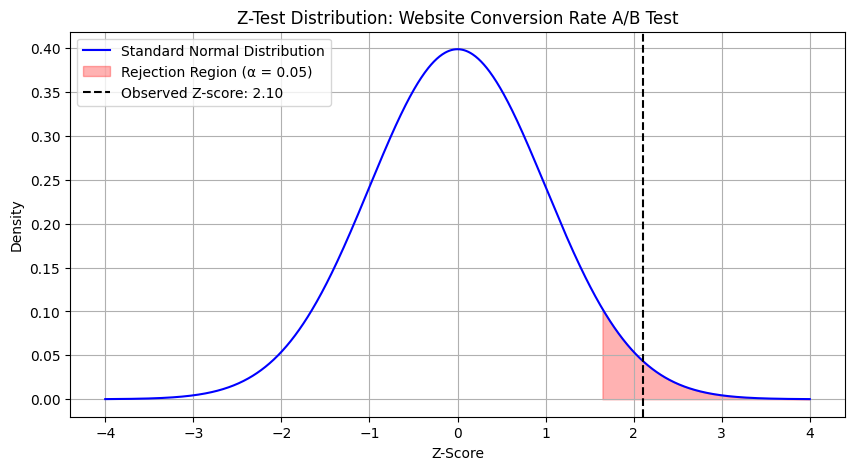

In [8]:
#normal distribution curve
import matplotlib.pyplot as plt
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)  # Standard normal distribution (mean=0, std=1)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Standard Normal Distribution", color='blue')

#(right-tailed test)
plt.fill_between(x, y, where=(x >= z_critical), color='red', alpha=0.3, label="Rejection Region (α = 0.05)")

#observed Z-score
plt.axvline(z_score, color='black', linestyle="--", label=f"Observed Z-score: {z_score:.2f}")

#for plot
plt.title("Z-Test Distribution: Website Conversion Rate A/B Test")
plt.xlabel("Z-Score")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()